<a href="https://colab.research.google.com/github/dv919/Fraud_Detection/blob/master/CNN_vs_ViT_vs_ResNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
!pip install timm

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms

BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

classes = trainset.classes

100%|██████████| 170M/170M [00:12<00:00, 13.8MB/s]


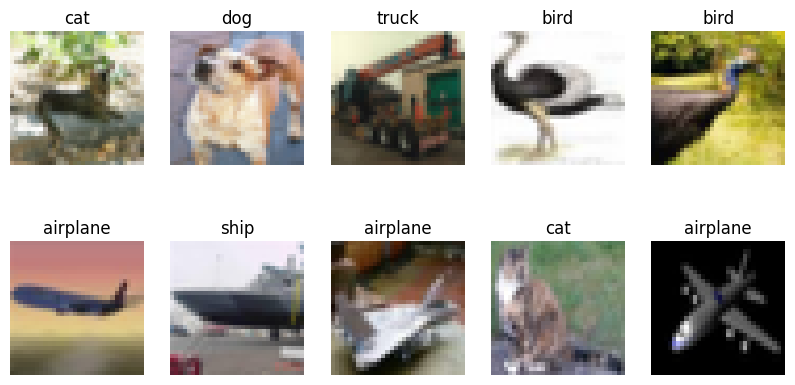

In [4]:
import matplotlib.pyplot as plt

images, labels = next(iter(trainloader))

fig, axes = plt.subplots(2,5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    img = images[i]/2 + 0.5
    ax.imshow(img.permute(1,2,0))
    ax.set_title(classes[labels[i]])
    ax.axis('off')

plt.show()

In [5]:
import torch.nn as nn

class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128*4*4,256),
            nn.ReLU(),
            nn.Linear(256,10)
        )

    def forward(self,x):

        x = self.features(x)

        x = x.view(x.size(0),-1)

        x = self.classifier(x)

        return x

In [6]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

In [7]:
import time
import torch.optim as optim

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

def train_model(model, trainloader, epochs=10):

    model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    losses = []

    start = time.time()

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(trainloader)

        losses.append(avg_loss)

        print(
            f"Epoch {epoch+1}: {avg_loss:.4f}"
        )

    training_time = time.time() - start

    return losses, training_time

In [8]:
def evaluate(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    return 100 * correct / total

In [10]:
cnn = CNN()

cnn_losses, cnn_time = train_model(
    cnn,
    trainloader,
    epochs=5
)

cnn_acc = evaluate(cnn)

print(cnn_acc)

Epoch 1: 1.4422
Epoch 2: 1.0268
Epoch 3: 0.8333
Epoch 4: 0.7008
Epoch 5: 0.6056
74.37


In [18]:
!pip install -q timm

In [19]:
import timm

In [20]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import timm
import time

from torch.utils.data import DataLoader

In [21]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [11]:
vit_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

In [22]:
vit_trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=vit_transform
)

vit_testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=vit_transform
)

In [23]:
vit = timm.create_model(
    'vit_tiny_patch16_224',
    pretrained=False,
    num_classes=10
)

vit = vit.to(device)

In [24]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

print(count_parameters(vit))

5526346


In [25]:
criterion = nn.CrossEntropyLoss()

In [26]:
optimizer = torch.optim.Adam(
    vit.parameters(),
    lr=0.001
)

In [27]:
def train_vit(model, trainloader, epochs=5):

    losses = []

    start_time = time.time()

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = (
            running_loss / len(trainloader)
        )

        losses.append(epoch_loss)

        print(
            f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}"
        )

    training_time = (
        time.time() - start_time
    )

    return losses, training_time

In [29]:
vit_losses, vit_time = train_vit(
    vit,
    vit_trainloader,
    epochs=5
)

Epoch 1/5, Loss: 1.8672
Epoch 2/5, Loss: 1.6077
Epoch 3/5, Loss: 1.4625
Epoch 4/5, Loss: 1.3553
Epoch 5/5, Loss: 1.2668


In [30]:
def evaluate_vit(model, testloader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = (
        100 * correct / total
    )

    return accuracy

In [31]:
vit_acc = evaluate_vit(
    vit,
    vit_testloader
)

print(
    f"ViT Accuracy: {vit_acc:.2f}%"
)

ViT Accuracy: 52.63%


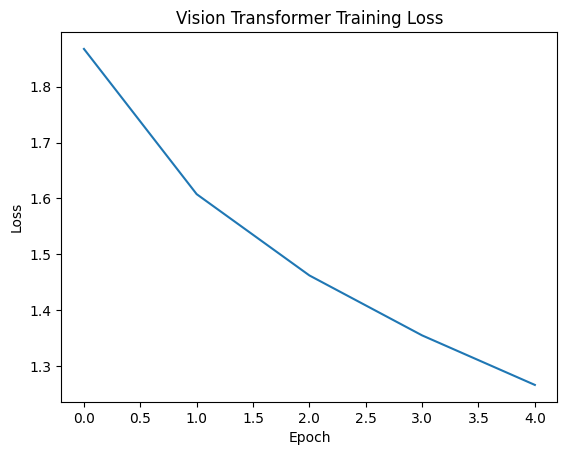

In [32]:
import matplotlib.pyplot as plt

plt.plot(vit_losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Vision Transformer Training Loss"
)

plt.show()

In [33]:
from torchvision.models import resnet18
import torch.nn as nn

In [34]:
resnet = resnet18(weights=None)

In [35]:
resnet.fc = nn.Linear(
    resnet.fc.in_features,
    10
)

In [36]:
resnet = resnet.to(device)

In [37]:
criterion = nn.CrossEntropyLoss()

In [38]:
optimizer = torch.optim.Adam(
    resnet.parameters(),
    lr=0.001
)

In [39]:
import time

def train_resnet(model, trainloader, epochs=5):

    losses = []

    start_time = time.time()

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)

        losses.append(epoch_loss)

        print(
            f"Epoch {epoch+1}/{epochs}, Loss={epoch_loss:.4f}"
        )

    training_time = (
        time.time() - start_time
    )

    return losses, training_time

In [40]:
resnet_losses, resnet_time = train_resnet(
    resnet,
    trainloader,
    epochs=5
)

Epoch 1/5, Loss=1.3799
Epoch 2/5, Loss=0.9833
Epoch 3/5, Loss=0.7930
Epoch 4/5, Loss=0.6692
Epoch 5/5, Loss=0.5642


In [41]:
def evaluate_resnet(model, testloader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    return 100 * correct / total

In [42]:
resnet_acc = evaluate_resnet(
    resnet,
    testloader
)

print(
    f"ResNet Accuracy: {resnet_acc:.2f}%"
)

ResNet Accuracy: 72.05%


In [43]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

print(
    count_parameters(resnet)
)

11181642


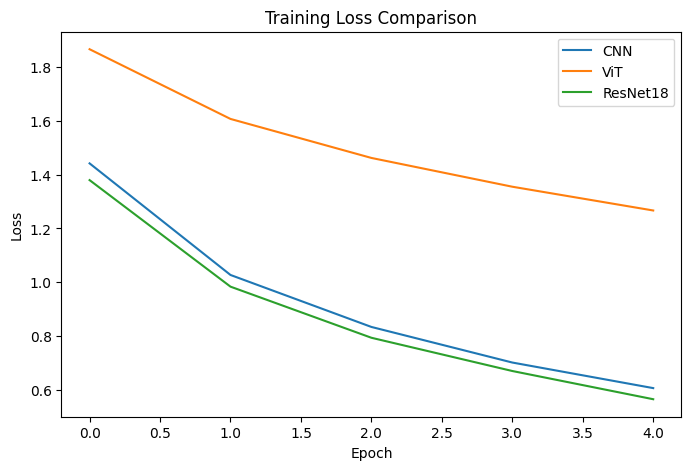

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(cnn_losses,label="CNN")
plt.plot(vit_losses,label="ViT")
plt.plot(resnet_losses,label="ResNet18")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")

plt.legend()

plt.show()

In [45]:
import pandas as pd

results = pd.DataFrame({

    "Model":[
        "CNN",
        "ResNet18",
        "Vision Transformer"
    ],

    "Accuracy (%)":[
        cnn_acc,
        resnet_acc,
        vit_acc
    ]
})

print(results)

                Model  Accuracy (%)
0                 CNN         74.37
1            ResNet18         72.05
2  Vision Transformer         52.63
